# Part 1 - Analysis

## Import Libraries

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pl.Config.restore_defaults()

polars.config.Config

In [3]:
# Set the streaming engine as the default for all future operations
pl.Config.set_engine_affinity("streaming")
# Show all rows
pl.Config.set_tbl_rows(-1)

polars.config.Config

## Load Data

In [4]:
transaction_data = pl.scan_parquet(
    "../data/filtered_cleaned_transactions.parquet"
)

In [5]:
transaction_data.head(5).collect()

Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Transfer Type
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64,str
2022-08-01 00:15:00,20,"""800104D70""",20,"""800104D70""",8095.07,"""US Dollar""",8095.07,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:18:00,3196,"""800107150""",3196,"""800107150""",7739.29,"""US Dollar""",7739.29,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:23:00,1208,"""80010E430""",1208,"""80010E430""",2654.22,"""US Dollar""",2654.22,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:19:00,3203,"""80010EA80""",3203,"""80010EA80""",13284.41,"""US Dollar""",13284.41,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""
2022-08-01 00:27:00,20,"""800104D20""",20,"""800104D20""",9.72,"""US Dollar""",9.72,"""US Dollar""","""Reinvestment""",0,"""Self-Transfer"""


## EDA 1 - Dataset Overview

In [6]:
# Get columns
transaction_data.collect_schema()

Schema([('Timestamp', Datetime(time_unit='us', time_zone=None)),
        ('From Bank', Int64),
        ('From Account', String),
        ('To Bank', Int64),
        ('To Account', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64),
        ('Transfer Type', String)])

In [7]:
# Get a summary of total transactions and unique counts of some columns
dataset_summary = transaction_data.select([
    pl.len().alias("Transactions"),

    pl.col("From Bank").n_unique().alias("Unique From Banks"),
    pl.col("To Bank").n_unique().alias("Unique To Banks"),

    pl.col("From Account").n_unique().alias("Unique From Accounts"),
    pl.col("To Account").n_unique().alias("Unique To Accounts"),

    pl.col("Payment Currency").n_unique().alias("Payment Currencies"),
    pl.col("Receiving Currency").n_unique().alias("Receiving Currencies"),
    pl.col("Payment Format").n_unique().alias("Payment Formats")
]).collect()

dataset_summary

Transactions,Unique From Banks,Unique To Banks,Unique From Accounts,Unique To Accounts,Payment Currencies,Receiving Currencies,Payment Formats
u32,u32,u32,u32,u32,u32,u32,u32
176060109,119618,61525,2023404,1678924,15,15,7


In [8]:
# Get class distribution for 'Is Laundering' column
transaction_data.group_by("Is Laundering").agg(pl.len().alias("Count")).with_columns(
    (
        pl.col("Count") / pl.col("Count").sum() * 100
    )
    .alias("Percentage")).sort("Is Laundering").collect()

Is Laundering,Count,Percentage
i64,u32,f64
0,175963171,99.94494
1,96938,0.05506


In [35]:
# Store total transactions, total laundered transactions and calculate % laundering
total_transactions = transaction_data.select(pl.len()).collect().item()

total_laundering = (
    transaction_data
    .select(pl.col("Is Laundering").sum())
    .collect()
    .item()
)

baseline_rate = total_laundering / total_transactions * 100

## EDA 2: Transaction Amounts

### 2.1 Amount Paid and Received

In [9]:
# Get summary statistics of amounts paid and received
amount_stats = transaction_data.select([
    pl.col("Amount Paid").count().alias("paid_count"),
    pl.col("Amount Paid").mean().alias("paid_mean"),
    pl.col("Amount Paid").median().alias("paid_median"),
    pl.col("Amount Paid").std().alias("paid_std"),
    pl.col("Amount Paid").min().alias("paid_min"),
    pl.col("Amount Paid").quantile(0.01).alias("paid_p01"),
    pl.col("Amount Paid").quantile(0.05).alias("paid_p05"),
    pl.col("Amount Paid").quantile(0.25).alias("paid_p25"),
    pl.col("Amount Paid").quantile(0.50).alias("paid_p50"),
    pl.col("Amount Paid").quantile(0.75).alias("paid_p75"),
    pl.col("Amount Paid").quantile(0.95).alias("paid_p95"),
    pl.col("Amount Paid").quantile(0.99).alias("paid_p99"),
    pl.col("Amount Paid").quantile(0.999).alias("paid_p999"),
    pl.col("Amount Paid").max().alias("paid_max"),

    pl.col("Amount Received").count().alias("received_count"),
    pl.col("Amount Received").mean().alias("received_mean"),
    pl.col("Amount Received").median().alias("received_median"),
    pl.col("Amount Received").std().alias("received_std"),
    pl.col("Amount Received").min().alias("received_min"),
    pl.col("Amount Received").quantile(0.01).alias("received_p01"),
    pl.col("Amount Received").quantile(0.05).alias("received_p05"),
    pl.col("Amount Received").quantile(0.25).alias("received_p25"),
    pl.col("Amount Received").quantile(0.50).alias("received_p50"),
    pl.col("Amount Received").quantile(0.75).alias("received_p75"),
    pl.col("Amount Received").quantile(0.95).alias("received_p95"),
    pl.col("Amount Received").quantile(0.99).alias("received_p99"),
    pl.col("Amount Received").quantile(0.999).alias("received_p999"),
    pl.col("Amount Received").max().alias("received_max"),
]).collect()

amount_stats

paid_count,paid_mean,paid_median,paid_std,paid_min,paid_p01,paid_p05,paid_p25,paid_p50,paid_p75,paid_p95,paid_p99,paid_p999,paid_max,received_count,received_mean,received_median,received_std,received_min,received_p01,received_p05,received_p25,received_p50,received_p75,received_p95,received_p99,received_p999,received_max
u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
176060109,4.8849e6,1380.95,1.2896e9,0.000001,0.045269,11.02,202.73,1380.95,10958.38,507442.67,1.0553e7,2.9525e8,4.8346e12,176060109,7.2646e6,1377.95,1.7056e9,0.000001,0.042008,10.85,201.39,1377.95,11023.17,530662.76,1.1674e7,3.4394e8,4.8346e12


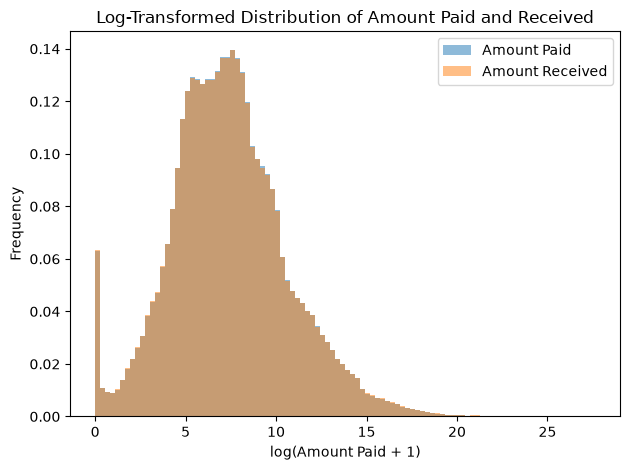

In [13]:
# Get a random sample of 1M "Amount Paid" from the 176M transactions - Speeds up processing
paid_sample = (
    transaction_data
    .select("Amount Paid")
    .collect(engine="streaming")
    .sample(n=1_000_000, seed=42)
)

# Get a random sample of 1M "Amount Received" from the 176M transactions - Speeds up processing
received_sample = (
    transaction_data
    .select("Amount Received")
    .collect(engine="streaming")
    .sample(n=1_000_000, seed=42)
)

# Convert to log(amount paid + 1) due to the extreme right-skewed data
paid_log = np.log1p(paid_sample["Amount Paid"].to_numpy())
received_log = np.log1p(received_sample["Amount Received"].to_numpy())

# Plot histogram
plt.hist(
    paid_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Amount Paid"
)

plt.hist(
    received_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Amount Received"
)

plt.xlabel("log(Amount Paid + 1)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Amount Paid and Received")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Investigate spike at zero
bar_at_zero = transaction_data.select([
    (pl.col("Amount Paid") == 0).sum().alias("zero_paid"),
    (pl.col("Amount Received") == 0).sum().alias("zero_received"),
    pl.col("Amount Paid").is_null().sum().alias("null_paid"),
    pl.col("Amount Received").is_null().sum().alias("null_received"),

    (pl.col("Amount Paid") < 0.01).sum().alias("paid<0.01"),
    (pl.col("Amount Paid") < 1).sum().alias("paid<1"),
    (pl.col("Amount Paid") < 10).sum().alias("paid<10"),
    (pl.col("Amount Received") < 0.01).sum().alias("received<0.01"),
    (pl.col("Amount Received") < 1).sum().alias("received<1"),
    (pl.col("Amount Received") < 10).sum().alias("received<10"),
]).collect()

bar_at_zero

zero_paid,zero_received,null_paid,null_received,paid<0.01,paid<1,paid<10,received<0.01,received<1,received<10
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,785077,3818980,8387167,836903,3842201,8455353


### 2.2 Paid vs Received Relationship

In [ ]:
# Investigate same currency and cross currency
# Expect same currency to have same amount paid and received
# Expect cross currency to have different amount paid and received
currency_relationship = (
    transaction_data
    .with_columns(
        (pl.col("Payment Currency") == pl.col("Receiving Currency"))
        .alias("same_currency")
    )
    .group_by("same_currency")
    .agg([
        pl.len().alias("transactions"),

        (
            pl.col("Amount Paid") == pl.col("Amount Received")
        ).sum().alias("exactly_equal"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received")).abs()
        ).median().alias("median_absolute_difference"),

        (
            (pl.col("Amount Paid") - pl.col("Amount Received")).abs()
        ).mean().alias("mean_absolute_difference"),

        pl.corr(
            "Amount Paid",
            "Amount Received"
        ).alias("correlation")
    ])
    .collect()
)

currency_relationship

same_currency,transactions,exactly_equal,median_absolute_difference,mean_absolute_difference,correlation
bool,u32,u32,f64,f64,f64
false,2694659,380,576.88,1.5630e8,0.330972
true,173365450,173365450,0.0,0.0,1.0


### 2.3 Extreme Values

In [17]:
# Observe the top amounts paid
extreme_paid = (
    transaction_data
    .sort("Amount Paid", descending=True)
    .head(5)
    .collect()
)

extreme_paid

Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Transfer Type
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64,str
2022-09-25 09:03:00,44763,"""810E31F70""",245868,"""810E53290""",4.8346e12,"""Yen""",4.8346e12,"""Yen""","""ACH""",0,"""Cross-Bank Transfer"""
2022-08-25 06:37:00,240864,"""810C6DCE0""",243641,"""810C73E00""",3.2149e12,"""Yen""",3.2149e12,"""Yen""","""ACH""",0,"""Cross-Bank Transfer"""
2022-11-03 12:15:00,74940,"""81CB661F0""",77357,"""81C128390""",2.3655e12,"""Ruble""",2.3655e12,"""Ruble""","""ACH""",0,"""Cross-Bank Transfer"""
2022-10-30 12:25:00,8640,"""805F83E00""",74695,"""820201D40""",2.0206e12,"""Ruble""",2.0206e12,"""Ruble""","""Cash""",0,"""Cross-Bank Transfer"""
2022-08-01 10:17:00,8640,"""805F83E00""",74695,"""820201D40""",2.0206e12,"""Ruble""",2.0206e12,"""Ruble""","""Cash""",0,"""Cross-Bank Transfer"""


## EDA 3 - Temporal Behaviour

### 3.1 Visualise daily transactions

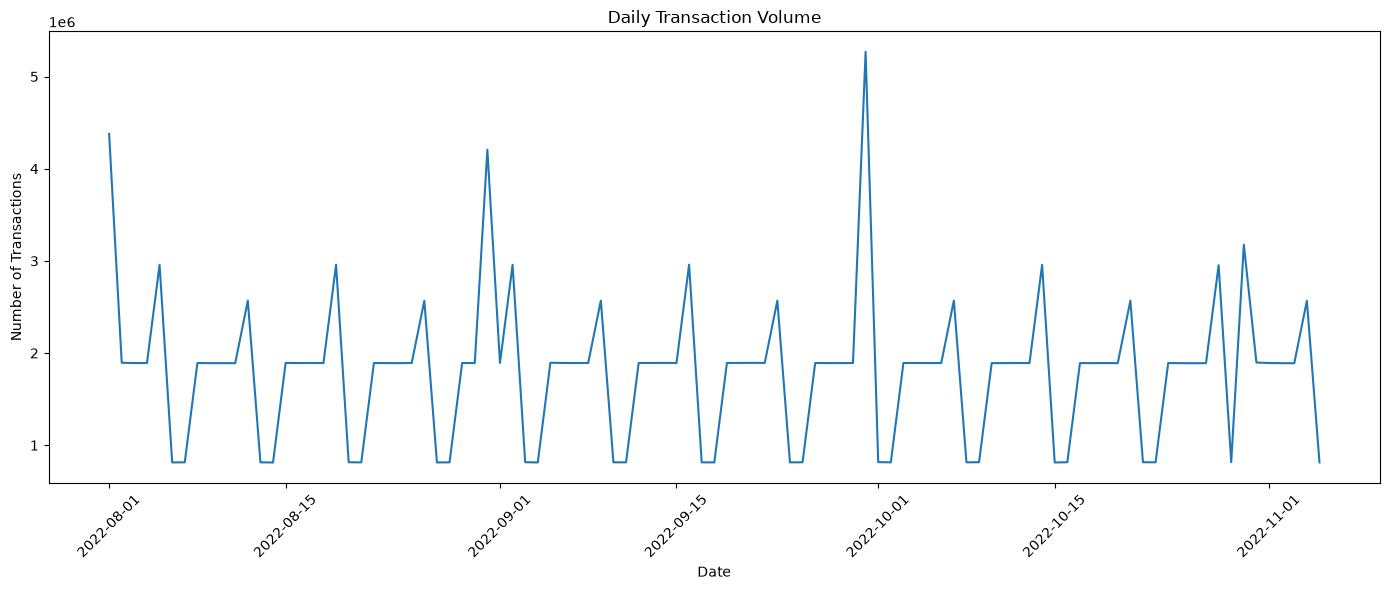

In [18]:
# Get transaction count for each day
daily_transactions = (
    transaction_data
    .group_by(
        pl.col("Timestamp").dt.date().alias("Date")
    )
    .agg(
        pl.len().alias("Transactions")
    )
    .sort("Date")
    .collect()
)

# Plot daily transaction volume
plt.figure(figsize=(14, 6))

plt.plot(
    daily_transactions["Date"],
    daily_transactions["Transactions"]
)

plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.title("Daily Transaction Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Laundering transactions over time

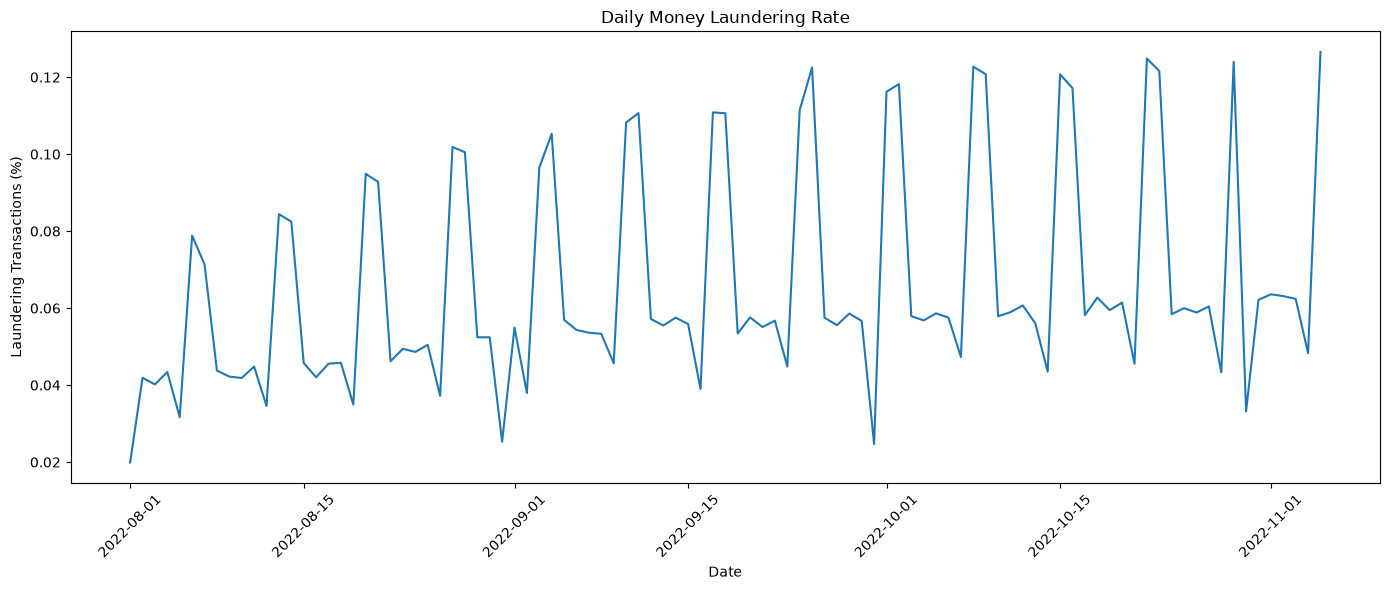

In [20]:
# Get number of laundered transactions for each day
daily_laundering = (
    transaction_data
    .with_columns(
        pl.col("Timestamp").dt.date().alias("Date")
    )
    .group_by("Date")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .sort("Date")
    .collect()
)

# Plot daily laundering transactions
plt.figure(figsize=(14, 6))

plt.plot(
    daily_laundering["Date"],
    daily_laundering["Laundering Rate"]
)

plt.xlabel("Date")
plt.ylabel("Laundering Transactions (%)")
plt.title("Daily Money Laundering Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## EDA 4 - Transaction characteristics

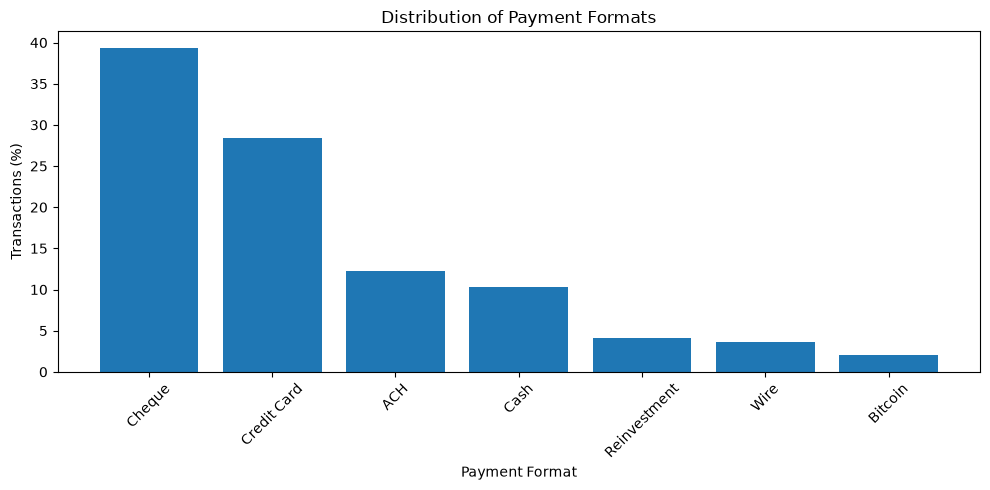

In [22]:
# Get payment format distribution
payment_formats = (
    transaction_data
    .group_by("Payment Format")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

# Plot bar graph
plt.figure(figsize=(10, 5))

plt.bar(
    payment_formats["Payment Format"],
    payment_formats["Percentage"]
)

plt.xlabel("Payment Format")
plt.ylabel("Transactions (%)")
plt.title("Distribution of Payment Formats")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
# Get payment currency distribution
payment_currencies = (
    transaction_data
    .group_by("Payment Currency")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

# Get receiving currency distribution
receiving_currencies = (
    transaction_data
    .group_by("Receiving Currency")
    .agg(pl.len().alias("Transactions"))
    .with_columns(
        (pl.col("Transactions") / pl.col("Transactions").sum() * 100)
        .alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

# Compare payment and receiving currency
currency_comparison = (
    payment_currencies
    .select([
        pl.col("Payment Currency").alias("Currency"),
        pl.col("Percentage").alias("Payment Percentage")
    ])
    .join(
        receiving_currencies.select([
            pl.col("Receiving Currency").alias("Currency"),
            pl.col("Percentage").alias("Receiving Percentage")
        ]),
        on="Currency"
    )
    .sort("Payment Percentage", descending=True)
)

currency_comparison

Currency,Payment Percentage,Receiving Percentage
str,f64,f64
"""US Dollar""",37.882953,37.602353
"""Euro""",23.569162,23.604704
"""Yuan""",5.42403,5.28
"""Rupee""",3.926794,3.9647
"""Canadian Dollar""",3.218709,3.256125
"""Swiss Franc""",3.149837,3.199158
"""Australian Dollar""",3.077443,3.122311
"""UK Pound""",3.042358,3.042143
"""Yen""",2.877877,2.896015


In [25]:
# Get transfer type distribution
transfer_types = (
    transaction_data
    .group_by("Transfer Type")
    .agg(
        pl.len().alias("Transactions")
    )
    .with_columns(
        (
            pl.col("Transactions") /
            pl.col("Transactions").sum() * 100
        ).alias("Percentage")
    )
    .sort("Transactions", descending=True)
    .collect()
)

transfer_types

Transfer Type,Transactions,Percentage
str,u32,f64
"""Cross-Bank Transfer""",164127373,93.222351
"""Self-Transfer""",10615154,6.029278
"""Standard Transfer""",1317582,0.748371


## EDA 5 - Money laundering patterns

### 5.1 Amount distributions by laundering status

In [26]:
# Get the statistics of legitimate and laundered transactions' amount paid and amount received
laundering_amount_stats = (
    transaction_data
    .group_by("Is Laundering")
    .agg([
        pl.len().alias("Transactions"),

        pl.col("Amount Paid").mean().alias("Paid Mean"),
        pl.col("Amount Paid").median().alias("Paid Median"),
        pl.col("Amount Paid").quantile(0.25).alias("Paid P25"),
        pl.col("Amount Paid").quantile(0.75).alias("Paid P75"),
        pl.col("Amount Paid").quantile(0.95).alias("Paid P95"),
        pl.col("Amount Paid").quantile(0.99).alias("Paid P99"),
        pl.col("Amount Paid").max().alias("Paid Max"),

        pl.col("Amount Received").mean().alias("Received Mean"),
        pl.col("Amount Received").median().alias("Received Median"),
        pl.col("Amount Received").quantile(0.25).alias("Received P25"),
        pl.col("Amount Received").quantile(0.75).alias("Received P75"),
        pl.col("Amount Received").quantile(0.95).alias("Received P95"),
        pl.col("Amount Received").quantile(0.99).alias("Received P99"),
        pl.col("Amount Received").max().alias("Received Max"),
    ])
    .sort("Is Laundering")
    .collect()
)

laundering_amount_stats

Is Laundering,Transactions,Paid Mean,Paid Median,Paid P25,Paid P75,Paid P95,Paid P99,Paid Max,Received Mean,Received Median,Received P25,Received P75,Received P95,Received P99,Received Max
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,175963171,4.8568e6,1379.61,202.58,10955.85,507473.15,1.0552e7,4.8346e12,7.2377e6,1376.62,201.24,11020.02,530779.12,1.1673e7,4.8346e12
1,96938,5.6028e7,3749.995,1318.36,14338.51,406488.8,1.4786e7,6.2154e11,5.6028e7,3749.995,1318.36,14338.51,406488.8,1.4786e7,6.2154e11


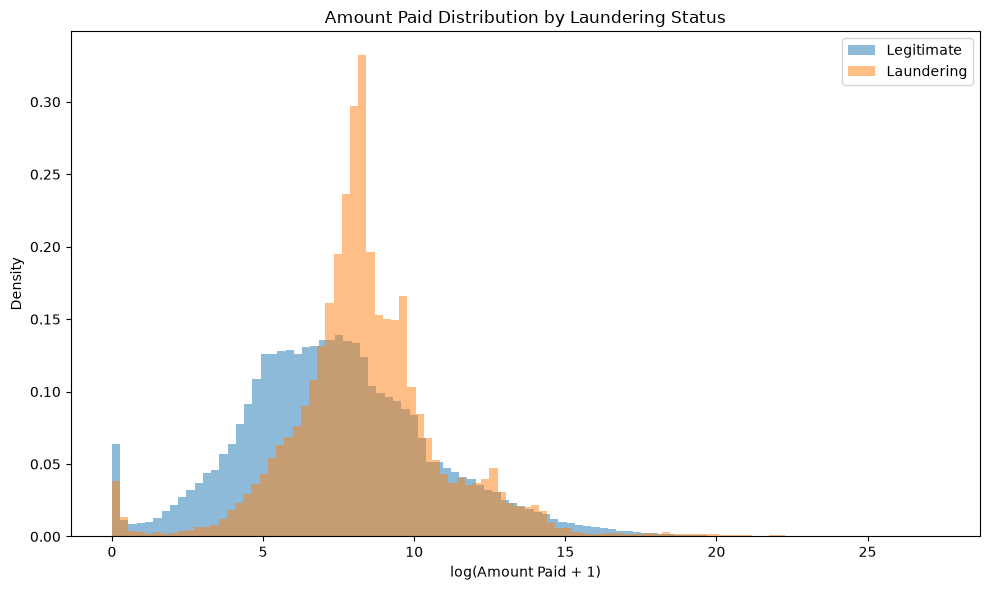

In [29]:
# Get all laundering transactions
laundering_amounts = (
    transaction_data
    .filter(pl.col("Is Laundering") == 1)
    .select("Amount Paid")
    .collect()
)

# Get a random selection of legitimate transactions
legitimate_amounts = (
    transaction_data
    .filter(pl.col("Is Laundering") == 0)
    .select("Amount Paid")
    .with_row_index("row_nr")
    .filter(pl.col("row_nr") % 1000 == 0)
    .select("Amount Paid")
    .collect()
)

laundering_log = np.log1p(laundering_amounts["Amount Paid"].to_numpy())
legitimate_log = np.log1p(legitimate_amounts["Amount Paid"].to_numpy())

# Plot histogram of legitimate and laundering
plt.figure(figsize=(10, 6))

plt.hist(
    legitimate_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    laundering_log,
    bins=100,
    density=True,
    alpha=0.5,
    label="Laundering"
)

plt.xlabel("log(Amount Paid + 1)")
plt.ylabel("Density")
plt.title("Amount Paid Distribution by Laundering Status")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Check same currency and cross currency for legitimate and laundered transactions
laundering_currency = (
    transaction_data
    .group_by("Is Laundering")
    .agg([
        pl.len().alias("Transactions"),

        (
            pl.col("Payment Currency") ==
            pl.col("Receiving Currency")
        )
        .sum()
        .alias("Same Currency"),

        (
            pl.col("Payment Currency") !=
            pl.col("Receiving Currency")
        )
        .sum()
        .alias("Cross Currency"),
    ])
    .with_columns([
        (
            pl.col("Same Currency") /
            pl.col("Transactions") * 100
        ).alias("Same Currency %"),

        (
            pl.col("Cross Currency") /
            pl.col("Transactions") * 100
        ).alias("Cross Currency %"),
    ])
    .sort("Is Laundering")
    .collect()
)

laundering_currency

Is Laundering,Transactions,Same Currency,Cross Currency,Same Currency %,Cross Currency %
i64,u32,u32,u32,f64,f64
0,175963171,173268512,2694659,98.468623,1.531377
1,96938,96938,0,100.0,0.0


### 5.2 Payment format vs laundering

In [36]:
# Get laundering statistics based on payment format
format_laundering = (
    transaction_data
    .group_by("Payment Format")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .sort("Laundering Rate", descending=True)
    .collect()
)

# Obtain relative risk for each category relative to overall laundering percentage
format_laundering = format_laundering.with_columns(
    (
        pl.col("Laundering Rate") / baseline_rate
    ).alias("Relative Risk")
)

format_laundering

Payment Format,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""ACH""",21561443,71367,0.330994,73.621284,6.011551
"""Bitcoin""",3586541,1497,0.041739,1.544286,0.758076
"""Cash""",18040752,3514,0.019478,3.624997,0.353764
"""Cheque""",69361333,13003,0.018747,13.413728,0.340481
"""Credit Card""",49911890,7554,0.015135,7.79261,0.274878
"""Wire""",6339912,3,0.000047,0.003095,0.000859
"""Reinvestment""",7258238,0,0.0,0.0,0.0


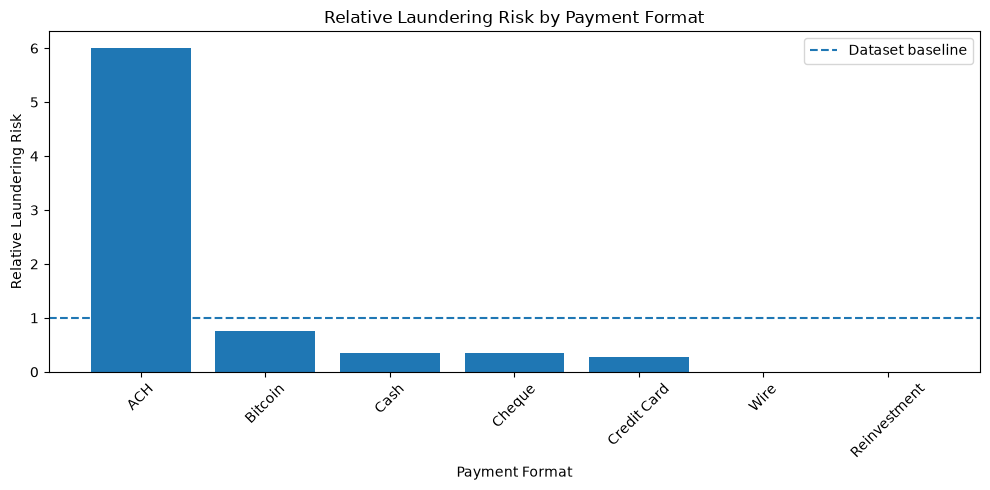

In [37]:
# Plot relative risk graph
plt.figure(figsize=(10, 5))

plt.bar(
    format_laundering["Payment Format"],
    format_laundering["Relative Risk"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Dataset baseline"
)

plt.xlabel("Payment Format")
plt.ylabel("Relative Laundering Risk")
plt.title("Relative Laundering Risk by Payment Format")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Transfer type vs laundering

In [39]:
# Check laundering rates based on the transfer type
transfer_laundering = (
    transaction_data
    .group_by("Transfer Type")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering Rate") / baseline_rate
        ).alias("Relative Risk")
    )
    .sort("Laundering Rate", descending=True)
    .collect()
)

transfer_laundering

Transfer Type,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""Cross-Bank Transfer""",164127373,96190,0.058607,99.228373,1.064427
"""Standard Transfer""",1317582,713,0.054114,0.735522,0.982831
"""Self-Transfer""",10615154,35,0.00033,0.036106,0.005988


### 5.4 Currency vs laundering

In [41]:
# Check laundering rates based on the payment currency used
currency_laundering = (
    transaction_data
    .group_by("Payment Currency")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            pl.col("Laundering").sum() * 100
        ).alias("Share of Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering Rate") / baseline_rate
        ).alias("Relative Risk")
    )
    .sort("Laundering Rate", descending=True)
    .collect()
)

currency_laundering

Payment Currency,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
str,u32,i64,f64,f64,f64
"""Yen""",5066793,3136,0.061893,3.235057,1.124113
"""Ruble""",4580566,2801,0.06115,2.889476,1.110608
"""Euro""",41495892,24712,0.059553,25.492583,1.081608
"""Yuan""",9549554,5411,0.056662,5.581918,1.029109
"""US Dollar""",66696768,36968,0.055427,38.135716,1.006672
"""Canadian Dollar""",5666862,3083,0.054404,3.180383,0.988093
"""Rupee""",6913517,3726,0.053894,3.843694,0.978838
"""UK Pound""",5356378,2846,0.053133,2.935897,0.965007
"""Australian Dollar""",5418149,2743,0.050626,2.829644,0.919479


### 5.5 Bank-level laundering patterns

In [44]:
# Get laundering transactions based on the originating bank
from_bank_laundering = (
    transaction_data
    .group_by("From Bank")
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering")
    ])
    .with_columns(
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate")
    )
    .collect()
)

In [45]:
# Get laundering statistics for the banks
bank_activity_stats = (
    from_bank_laundering
    .select([
        pl.col("Transactions").min().alias("Min"),
        pl.col("Transactions").quantile(0.25).alias("P25"),
        pl.col("Transactions").median().alias("Median"),
        pl.col("Transactions").quantile(0.75).alias("P75"),
        pl.col("Transactions").quantile(0.90).alias("P90"),
        pl.col("Transactions").quantile(0.95).alias("P95"),
        pl.col("Transactions").quantile(0.99).alias("P99"),
        pl.col("Transactions").max().alias("Max")
    ])
)

bank_activity_stats

Min,P25,Median,P75,P90,P95,P99,Max
u32,f64,f64,f64,f64,f64,f64,u32
1,6.0,18.0,70.0,168.0,411.0,35103.0,16716238


In [53]:
# Get top 15 laundering banks
top_banks_laundering_count = (
    from_bank_laundering
    .with_columns([
        (
            pl.col("Laundering") / total_laundering * 100
        ).alias("Share of Laundering"),
        (
            pl.col("Laundering Rate") / baseline_rate
        ).alias("Relative Risk")
    ]
    )
    .sort("Laundering", descending=True)
    .head(15)
)

top_banks_laundering_count

From Bank,Transactions,Laundering,Laundering Rate,Share of Laundering,Relative Risk
i64,u32,i64,f64,f64,f64
70,16716238,23647,0.141461,24.393943,2.569238
11,983200,378,0.038446,0.38994,0.698259
0,873192,301,0.034471,0.310508,0.626071
12,885707,249,0.028113,0.256865,0.510595
20,878243,245,0.027897,0.252739,0.506662
3,539399,224,0.041528,0.231076,0.754232
27,721684,183,0.025357,0.18878,0.460544
14,543767,175,0.032183,0.180528,0.58451
1226,332021,167,0.050298,0.172275,0.91352


In [55]:
# Check how concentrated laundering is overall relative to the banks
laundering_concentration = (
    from_bank_laundering
    .sort("Laundering", descending=True)
    .select([
        pl.col("Laundering").head(10).sum().alias("Top 10"),
        pl.col("Laundering").head(50).sum().alias("Top 50"),
        pl.col("Laundering").head(100).sum().alias("Top 100"),
    ])
    .with_columns([
        (pl.col("Top 10") / total_laundering * 100).alias("Top 10 %"),
        (pl.col("Top 50") / total_laundering * 100).alias("Top 50 %"),
        (pl.col("Top 100") / total_laundering * 100).alias("Top 100 %"),
    ])
)

laundering_concentration

Top 10,Top 50,Top 100,Top 10 %,Top 50 %,Top 100 %
i64,i64,i64,f64,f64,f64
25734,30005,33763,26.546865,30.952774,34.829479


## EDA 6 - Relationships and anomalous patterns

### 6.1 Repeated account pairs

In [56]:
# Get sender-receiver pairs
account_pairs = (
    transaction_data
    .group_by([
        "From Bank",
        "From Account",
        "To Bank",
        "To Account"
    ])
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering Transactions"),
        pl.col("Amount Paid").sum().alias("Total Amount"),
        pl.col("Amount Paid").mean().alias("Mean Amount"),
        pl.col("Timestamp").min().alias("First Transaction"),
        pl.col("Timestamp").max().alias("Last Transaction")
    ])
    .collect()
)

# Obtain the pair frequency statistics
pair_frequency_stats = (
    account_pairs
    .select([
        pl.col("Transactions").min().alias("Min"),
        pl.col("Transactions").quantile(0.25).alias("P25"),
        pl.col("Transactions").median().alias("Median"),
        pl.col("Transactions").quantile(0.75).alias("P75"),
        pl.col("Transactions").quantile(0.90).alias("P90"),
        pl.col("Transactions").quantile(0.95).alias("P95"),
        pl.col("Transactions").quantile(0.99).alias("P99"),
        pl.col("Transactions").max().alias("Max")
    ])
)

pair_frequency_stats

Min,P25,Median,P75,P90,P95,P99,Max
u32,f64,f64,f64,f64,f64,f64,u32
1,1.0,2.0,8.0,70.0,140.0,280.0,877


In [58]:
# Get how many sender-receiver pairs have a certain amount of transactions
repeated_pair_counts = (
    account_pairs
    .select([
        pl.len().alias("Unique Account Pairs"),

        (pl.col("Transactions") > 1)
        .sum()
        .alias("Repeated Pairs"),

        (pl.col("Transactions") >= 5)
        .sum()
        .alias("Pairs With 5+ Transactions"),

        (pl.col("Transactions") >= 10)
        .sum()
        .alias("Pairs With 10+ Transactions"),

        (pl.col("Transactions") >= 100)
        .sum()
        .alias("Pairs With 100+ Transactions")
    ])
)

repeated_pair_counts

Unique Account Pairs,Repeated Pairs,Pairs With 5+ Transactions,Pairs With 10+ Transactions,Pairs With 100+ Transactions
u32,u32,u32,u32,u32
8174301,4498964,2455922,1643579,694476


### 6.2 Pair repetition vs laundering

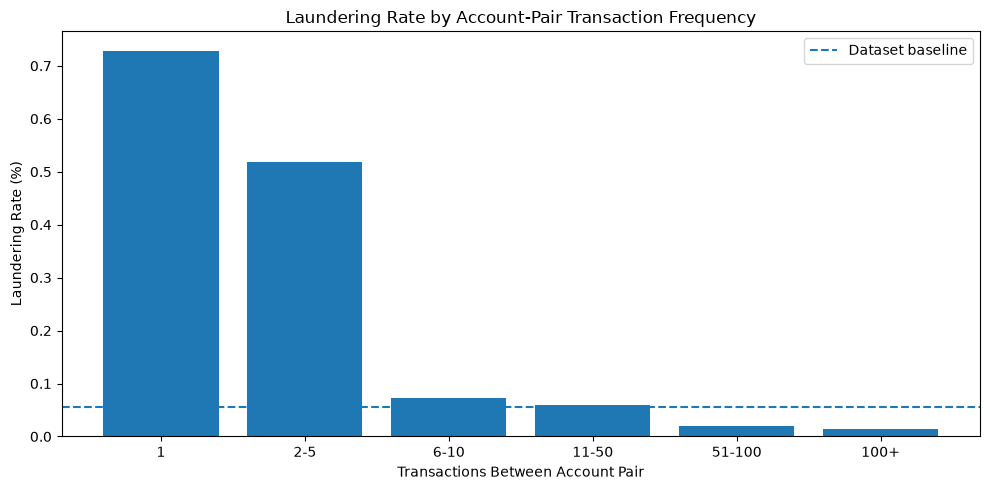

In [61]:
# Get laundering frequency based on sender-receiver frequency
pair_frequency_buckets = (
    account_pairs
    .with_columns(
        pl.when(pl.col("Transactions") == 1)
        .then(pl.lit("1"))

        .when(pl.col("Transactions") <= 5)
        .then(pl.lit("2-5"))

        .when(pl.col("Transactions") <= 10)
        .then(pl.lit("6-10"))

        .when(pl.col("Transactions") <= 50)
        .then(pl.lit("11-50"))

        .when(pl.col("Transactions") <= 100)
        .then(pl.lit("51-100"))

        .otherwise(pl.lit("100+"))
        .alias("Pair Frequency")
    )
    .group_by("Pair Frequency")
    .agg([
        pl.len().alias("Account Pairs"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering Transactions").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            total_laundering * 100
        ).alias("Share of Laundering")
    ])
)

bucket_order = ["1", "2-5", "6-10", "11-50", "51-100", "100+"]

pair_frequency_buckets = (
    pair_frequency_buckets
    .with_columns(
        pl.col("Pair Frequency").cast(pl.Enum(bucket_order))
    )
    .sort("Pair Frequency")
)

# Plot bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    pair_frequency_buckets["Pair Frequency"].cast(pl.String),
    pair_frequency_buckets["Laundering Rate"]
)

plt.axhline(
    y=baseline_rate,
    linestyle="--",
    label="Dataset baseline"
)

plt.xlabel("Transactions Between Account Pair")
plt.ylabel("Laundering Rate (%)")
plt.title("Laundering Rate by Account-Pair Transaction Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Reciprocal account-pair behaviour

In [65]:
# Get pairs that also match in the opposite direction
reciprocal_pairs = (
    transaction_data
    .with_columns([
        pl.concat_str(
            [
                pl.col("From Bank").cast(pl.String),
                pl.lit("_"),
                pl.col("From Account")
            ]
        ).alias("From Entity"),

        pl.concat_str(
            [
                pl.col("To Bank").cast(pl.String),
                pl.lit("_"),
                pl.col("To Account")
            ]
        ).alias("To Entity")
    ])
    .with_columns([
        pl.min_horizontal(
            "From Entity",
            "To Entity"
        ).alias("Entity A"),

        pl.max_horizontal(
            "From Entity",
            "To Entity"
        ).alias("Entity B")
    ])
    .group_by([
        "Entity A",
        "Entity B"
    ])
    .agg([
        pl.len().alias("Transactions"),
        pl.col("Is Laundering").sum().alias("Laundering"),
        pl.col("From Entity").n_unique().alias("Directions")
    ])
    .collect()
)

# Get laundering behaviour based on unidirectional or bidirectional behaviour
reciprocal_summary = (
    reciprocal_pairs
    .group_by("Directions")
    .agg([
        pl.len().alias("Account Relationships"),
        pl.col("Transactions").sum().alias("Transactions"),
        pl.col("Laundering").sum().alias("Laundering")
    ])
    .with_columns([
        (
            pl.col("Laundering") /
            pl.col("Transactions") * 100
        ).alias("Laundering Rate"),

        (
            pl.col("Laundering") /
            total_laundering * 100
        ).alias("Share of Laundering")
    ])
    .sort("Directions")
)

reciprocal_summary

Directions,Account Relationships,Transactions,Laundering,Laundering Rate,Share of Laundering
u32,u32,u32,i64,f64,f64
1,7196453,174281976,55696,0.031957,57.455281
2,488924,1778133,41242,2.319399,42.544719
